In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case)

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/00101
00101


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

In [7]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [8]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [9]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1':
    cntrl_vars_init = [1]
elif case[3] == '2':
    cntrl_vars_init = [0,1]
elif case[3] == '3':
    cntrl_vars_init = [0]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-3) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
    print(read_file)
elif case[3] == '4':
    cntrl_vars_init = [1]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-3) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
    print(read_file)
elif case[3] == '5':
    cntrl_vars_init = [0,1]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-3) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
    print(read_file)

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [10]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_' + case + '.pickle'
case_1 = case[0] + case[1] + '0' + case[3] + case[4]
final_file_1 = 'control_' + case_1 + '.pickle'

In [11]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [12]:
# get initial parameters and target states

i_stepsize = 5
i_range = range(0, len(exc),i_stepsize)
i_range_0 = range(0, len(exc),i_stepsize)
i_range_1 = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  5 0.4000000000000001 0.40000000000000013
-------  10 0.4250000000000001 0.42500000000000016
-------  15 0.4500000000000001 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  25 0.4250000000000001 0.5000000000000002
-------  30 0.4250000000000001 0.5250000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  40 0.5250000000000001 0.5500000000000003
-------  45 0.5000000000000002 0.5750000000000003
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
-------  65 0.5000000000000002 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  75 0.5750000000000002 0.6750000000000004
-------  80 0.5250000000000001 0.7000000000000004
-------  85 0.47500000000000014 0.7250000000000004
-------  90 0.6000000000000003 0.7250000000000004
-------  95 0.5250000000000001 0.750000000000000

In [13]:
# get uncontrolled cost

data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  5 0.4000000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5097.289828199723
Gradient descend method:  None
RUN  0 , total integrated cost =  5097.289828199723
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  10 0.4250000000000001 0.42500000000000016
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9111.456490210901
Gradient descend method:  None
RUN  0 , total integrated cost =  9111.456490210901
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  15 0.4500000000000001 0.4500000000000002

In [14]:
factor_iteration = 20.
aln.params.duration = dur

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
        
    ##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    
    if conv_init[i] == [True, True]:
    
        with open(read_file,'rb') as f:
            load_array = pickle.load(f)

        bestControl_read = load_array[0]

        bestControl_init[i] = np.zeros(( 1, 6, n_dur + n_pre + n_post -2 ))
        bestControl_init[i][:,:,n_pre-1:n_pre-1+1000] = bestControl_read[i][:,:,n_pre-1:n_pre-1+1000].copy()
        
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]
                
        cost.setParams(weights_init[i][0], weights_init[i][1], weights_init[i][2])

        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        
        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = 0, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        continue
    
    aln.params.duration = dur
    
    if not type(bestControl_init[i]) == type(None):
        continue
        
    control0 = aln.getZeroControl()

    ##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)

    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    with open(init_file,'wb') as f:
        pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

with open(init_file,'wb') as f:
        pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

-------  0 0.4000000000000001 0.3500000000000001
-------  5 0.4000000000000001 0.40000000000000013
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5097.289828199723
Gradient descend method:  None
RUN  1 , total integrated cost =  1533.85329848027
RUN  2 , total integrated cost =  1420.3112304440058
RUN  3 , total integrated cost =  1311.691313920088
RUN  4 , total integrated cost =  1204.8370353206992
RUN  5 , total integrated cost =  1105.0176186943809
RUN  6 , total integrated cost =  1006.8468845483197
RUN  7 , total integrated cost =  917.1323593074176
RUN  8 , total integrated cost =  831.4958247137422
RUN  9 , total integrated cost =  748.5812339613052
RUN  10 , total integrated cost =  674.7181539919778
RUN  11 , total integrated cost =  607.6652804022383
RUN  12 , total integrated cost =  549.9791890660676
RUN  13 , total integrated cost =  494.1751240063768
RUN  14 , total integrated cost =  448.12661476675584
RUN  15 , to

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  297 , total integrated cost =  4903.05250323841
Improved over  297  iterations in  18.718348555266857  seconds by  3.7870555083936637  percent.
Problem in initial value trasfer:  Vmean_exc -56.62445756602167 -56.62445772025889
-------  10 0.4250000000000001 0.42500000000000016
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9111.456490210901
Gradient descend method:  None
RUN  1 , total integrated cost =  2585.3285933740403
RUN  2 , total integrated cost =  1924.0573329830531
RUN  3 , total integrated cost =  1477.514709835759
RUN  4 , total integrated cost =  1171.156253187992
RUN  5 , total integrated cost =  943.9855399173222
RUN  6 , total integrated cost =  768.8975285342461
RUN  7 , total integrated cost =  644.8117126924849
RUN  8 , total integrated cost =  546.1654720432214
RUN  9 , total integrated cost =  472.3584540443773
RUN  10 , total integrated cost =  412.4989910633414
RUN  11 ,

ERROR:root:Problem in initial value trasfer


RUN  2000 , total integrated cost =  33.89590807443239
RUN  2000 , total integrated cost =  33.89590807443239
Improved over  2000  iterations in  124.49763539619744  seconds by  99.62798584275907  percent.
Problem in initial value trasfer:  Vmean_exc -56.64651747335298 -56.64651726467228
weight =  2688.0697428736694
set cost params:  1.0 0.0 2688.0697428736694
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9109.13587742532
Gradient descend method:  None
RUN  1 , total integrated cost =  9028.926851539238
RUN  2 , total integrated cost =  9021.596265346021
RUN  3 , total integrated cost =  9013.75901744609
RUN  4 , total integrated cost =  9010.320619466289
RUN  5 , total integrated cost =  9004.956909215516
RUN  6 , total integrated cost =  9001.871573712075
RUN  7 , total integrated cost =  8995.537380310258
RUN  8 , total integrated cost =  8991.035027529033
RUN  9 , total integrated cost =  8955.978617285049
RUN  10 , total integrated cost =  8937.9293959258

...

RUN  1 , total integrated cost =  14547.979043359295
Control only changes marginally.
RUN  1 , total integrated cost =  14547.979043359295
Improved over  1  iterations in  0.13796952925622463  seconds by  0.0  percent.
-------  130 0.6000000000000003 0.8500000000000005
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38727.35641379273
Gradient descend method:  None
RUN  1 , total integrated cost =  1646.221149645428
RUN  2 , total integrated cost =  1477.444884140541
RUN  3 , total integrated cost =  951.4167109093535
RUN  4 , total integrated cost =  82.82116079348994
RUN  5 , total integrated cost =  43.79538693782194
RUN  6 , total integrated cost =  37.56314523830336
RUN  7 , total integrated cost =  35.333289412575574
RUN  8 , total integrated cost =  34.20030634936611
RUN  9 , total integrated cost =  33.48147089377771
RUN  10 , total integrated cost =  32.94308224793461
RUN  11 , total integrated cost =  32.52738385892807
RUN

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  174 , total integrated cost =  38001.74301719766
Improved over  174  iterations in  11.72108755260706  seconds by  1.865195349431275  percent.
Problem in initial value trasfer:  Vmean_exc -56.70018722822266 -56.70018721141817
-------  135 0.5250000000000001 0.8750000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23532.636143093983
Gradient descend method:  None
RUN  1 , total integrated cost =  23532.636143093983
Control only changes marginally.
RUN  1 , total integrated cost =  23532.636143093983
Improved over  1  iterations in  0.156965222209692  seconds by  0.0  percent.
weight =  10.0
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23532.636143093983
Gradient descend method:  None
RUN  1 , total integrated cost =  23532.636143093983
Control only changes marginally.
RUN  1 , total integrated cost =  23532.636143093983
Improved

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  285 , total integrated cost =  30873.743843354463
Improved over  285  iterations in  18.84227130934596  seconds by  7.248709871897162  percent.
Problem in initial value trasfer:  Vmean_exc -56.70354248389189 -56.70354245740208


--------- 0


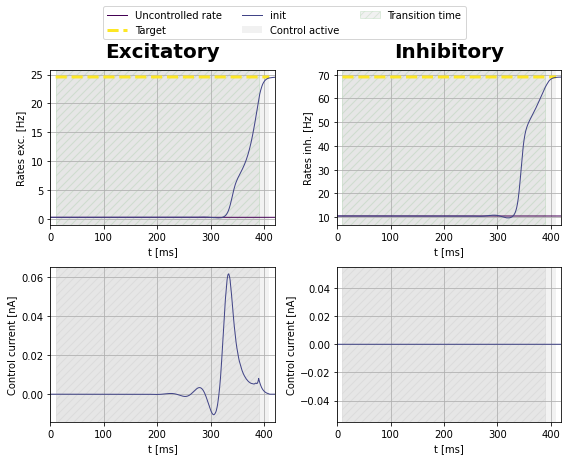

--------- 5


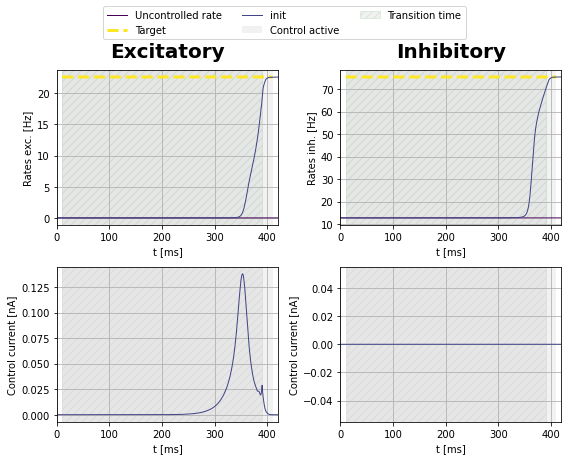

--------- 10


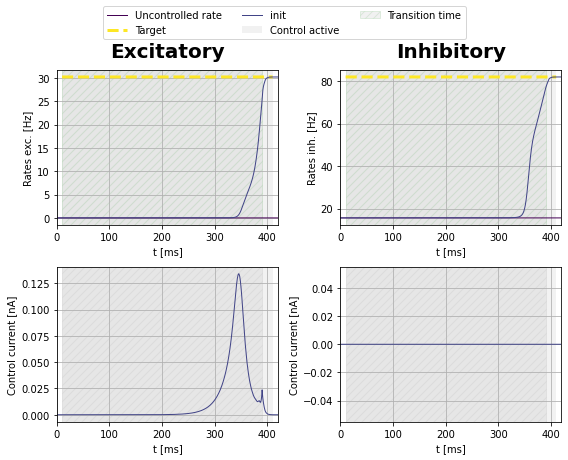

--------- 15


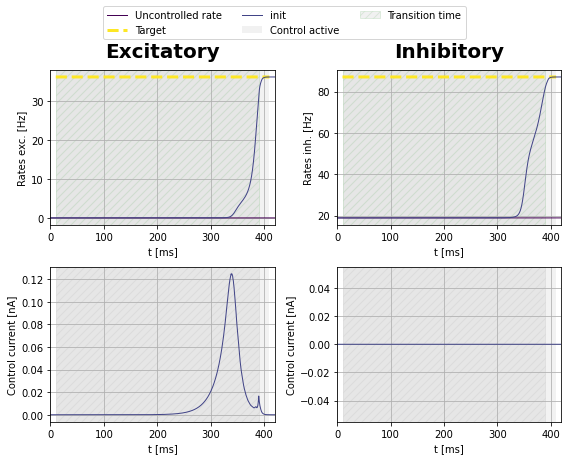

--------- 20


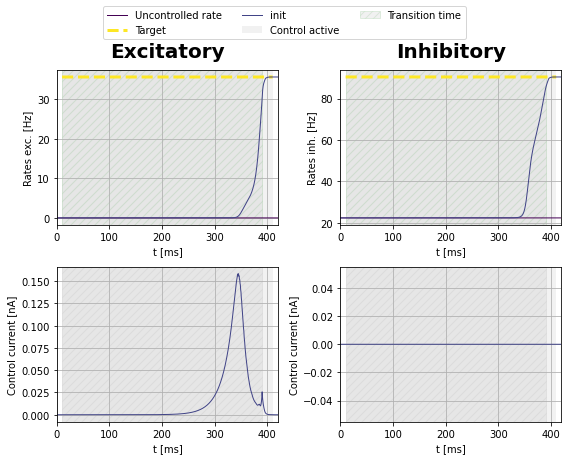

--------- 25


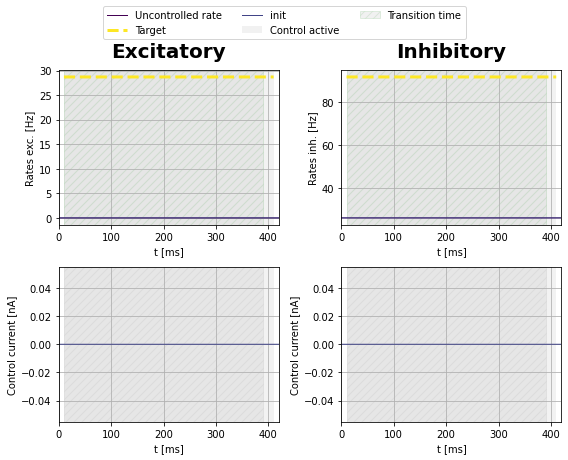

--------- 30


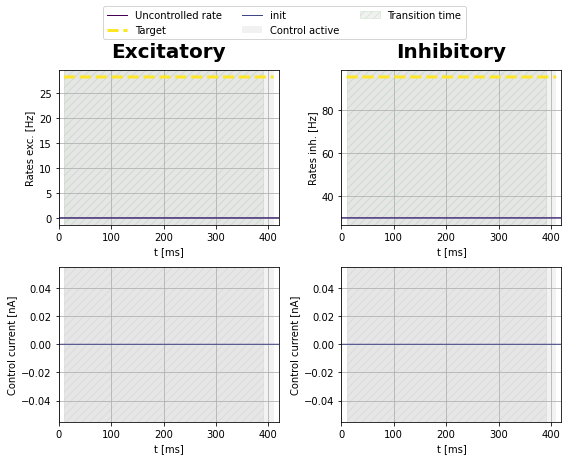

--------- 35


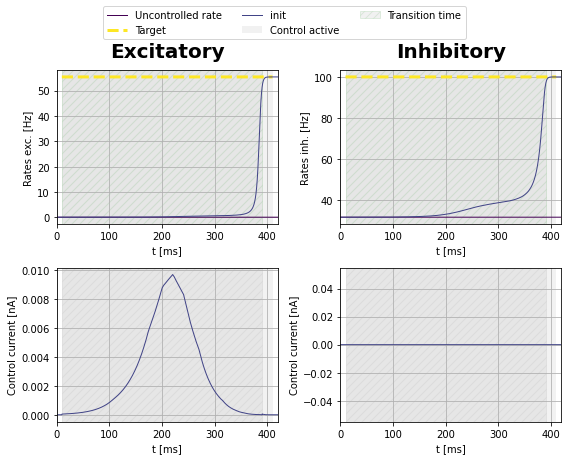

--------- 40


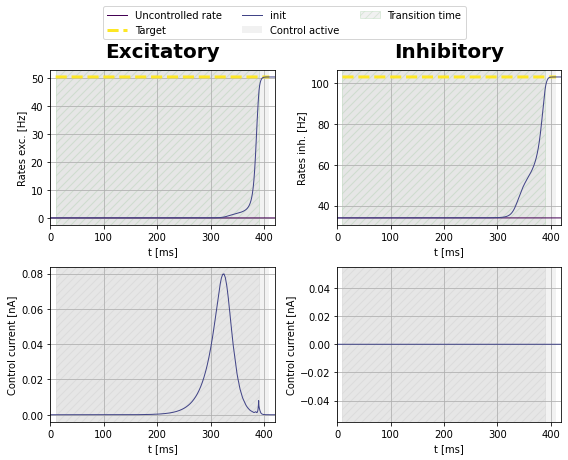

--------- 45


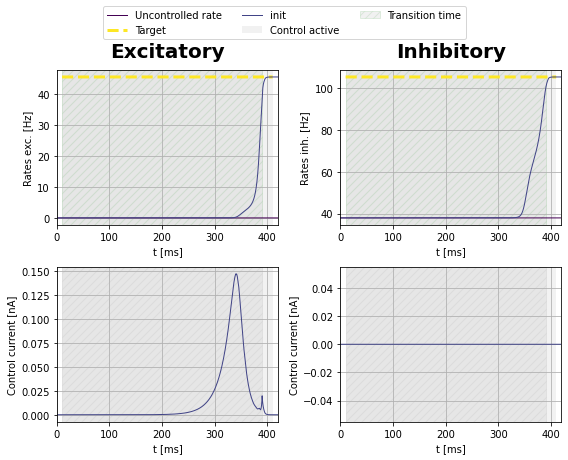

--------- 50


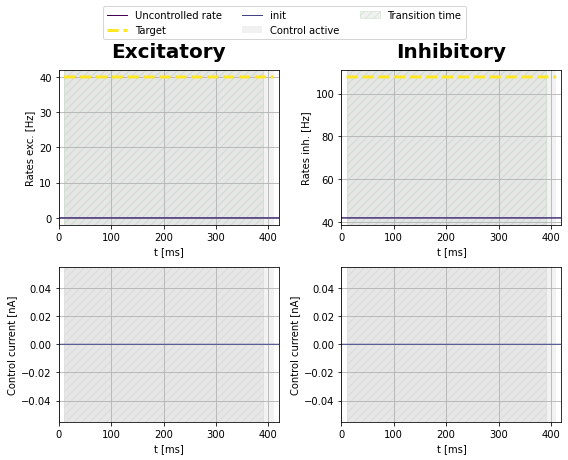

--------- 55


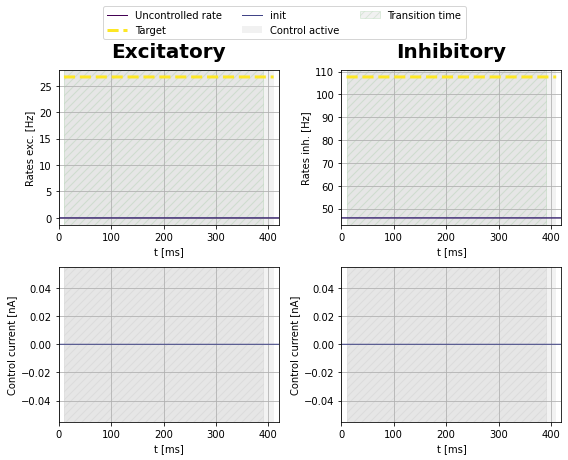

--------- 60


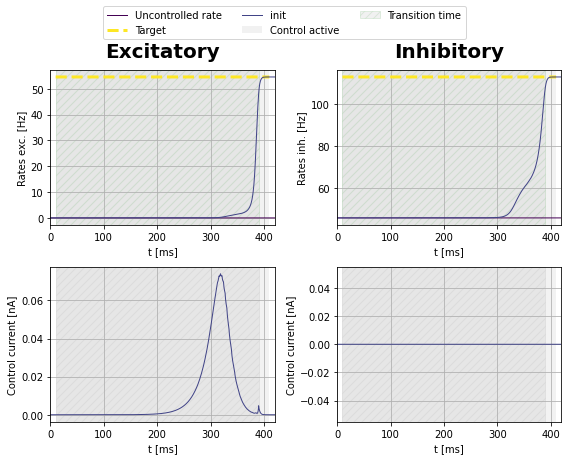

--------- 65


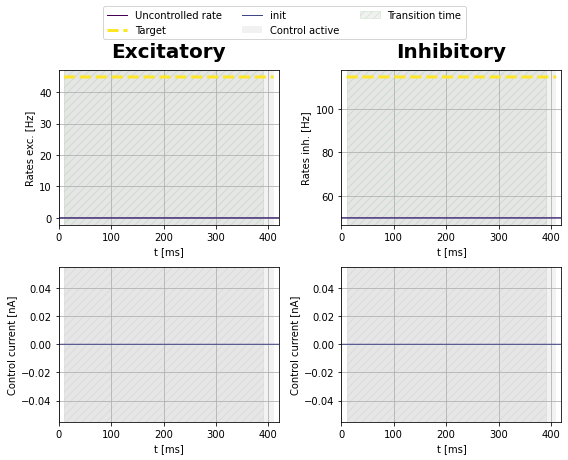

--------- 70


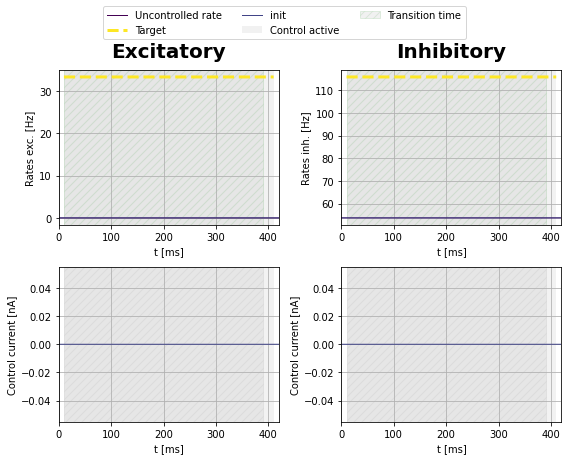

--------- 75


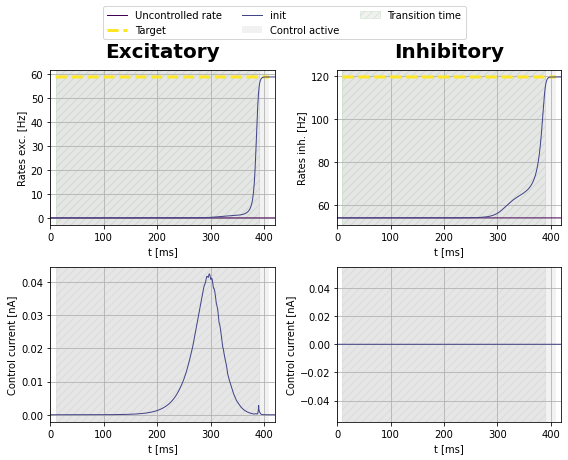

--------- 80


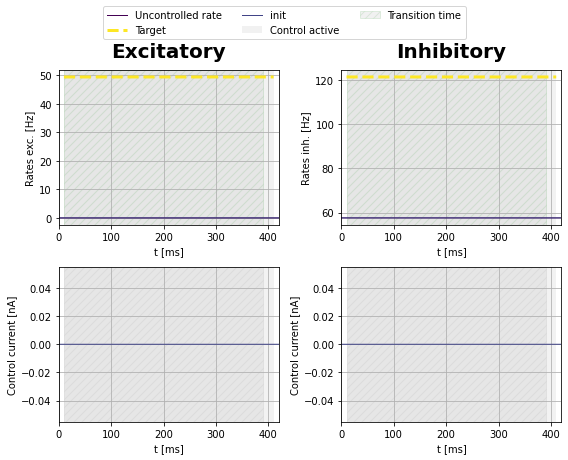

--------- 85


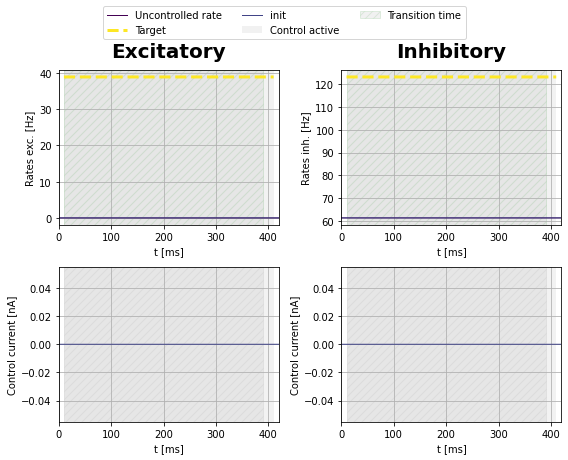

--------- 90


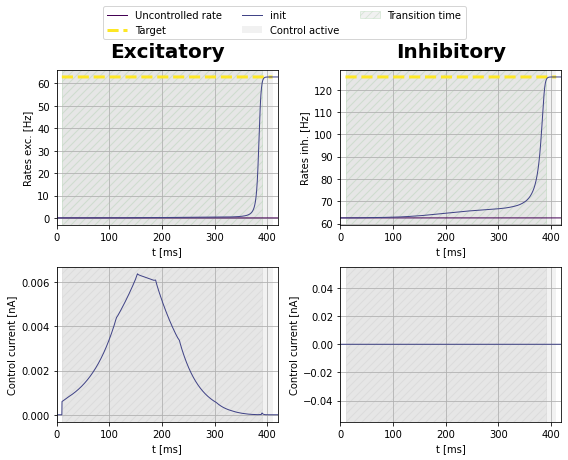

--------- 95


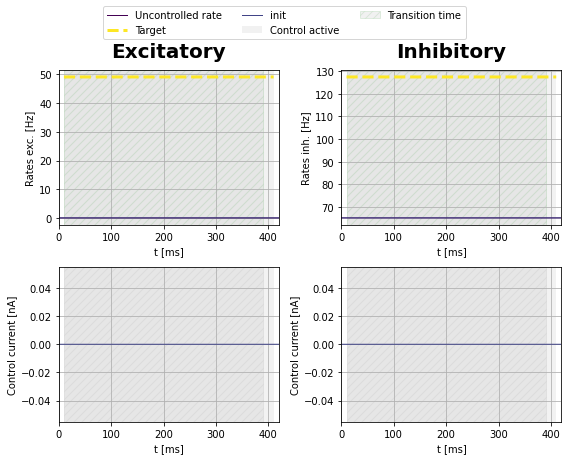

--------- 100


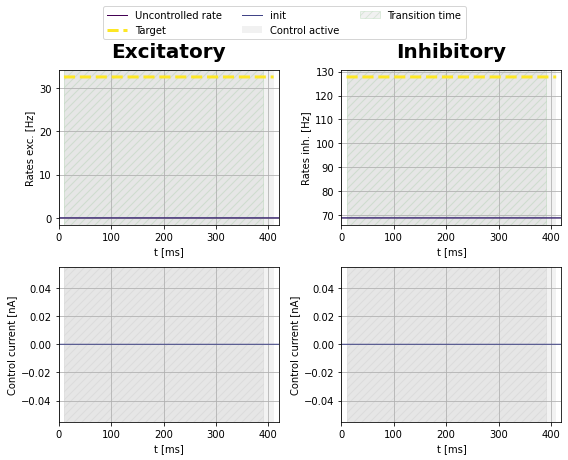

--------- 105


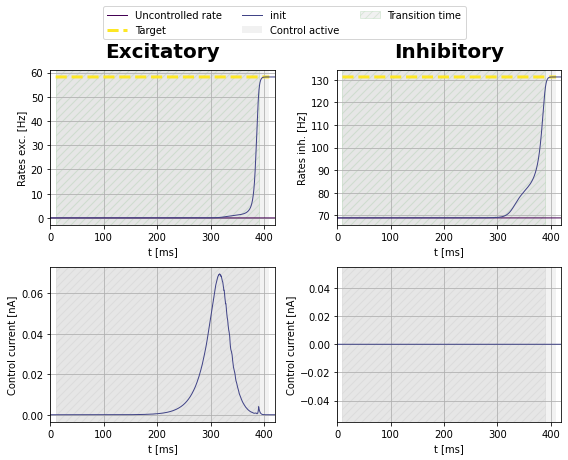

--------- 110


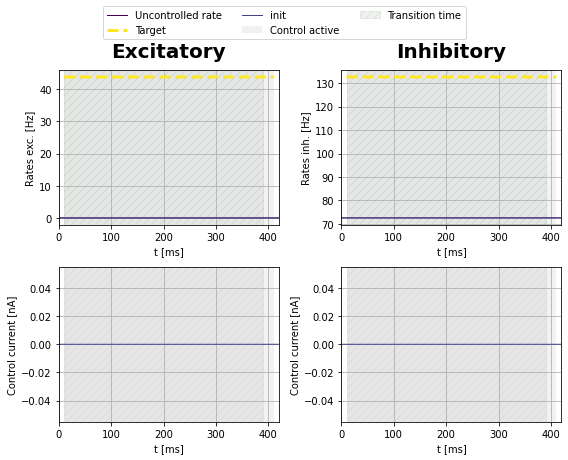

--------- 115


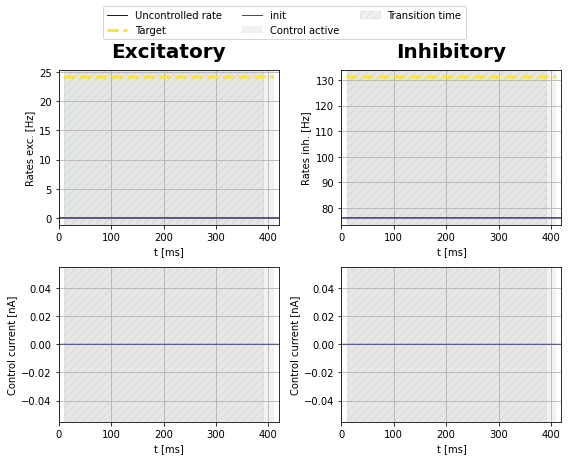

--------- 120


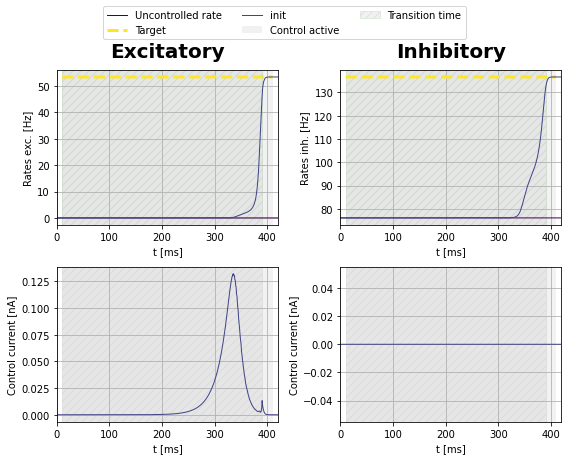

--------- 125


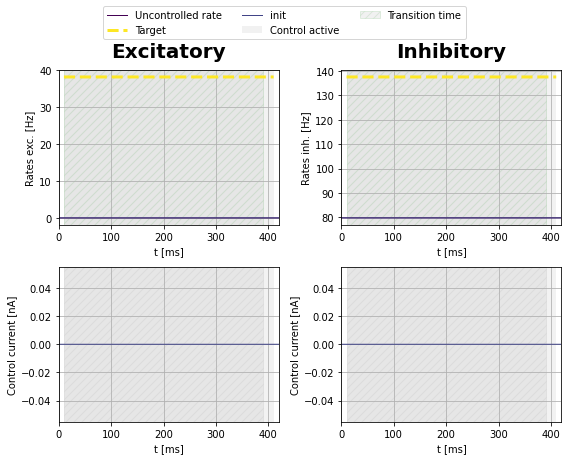

--------- 130


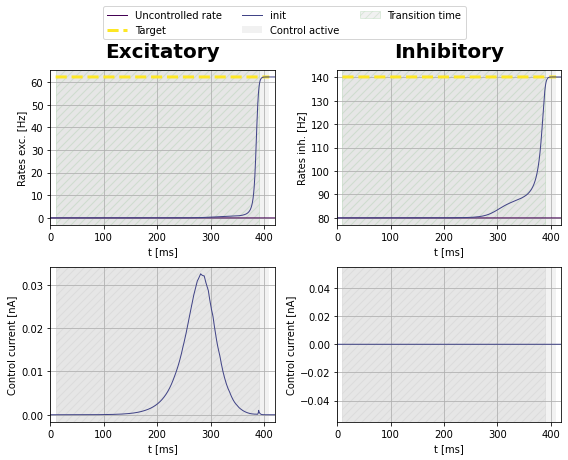

--------- 135


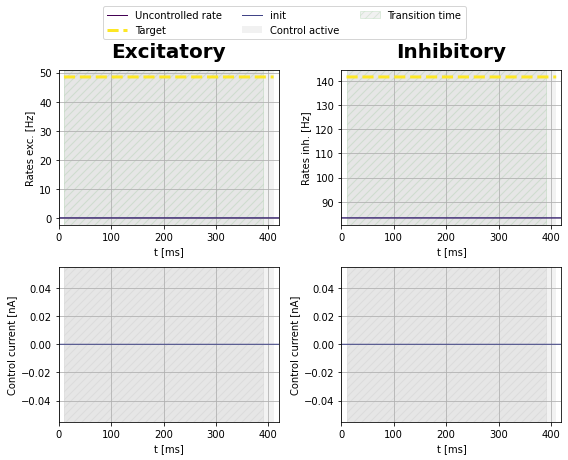

--------- 140


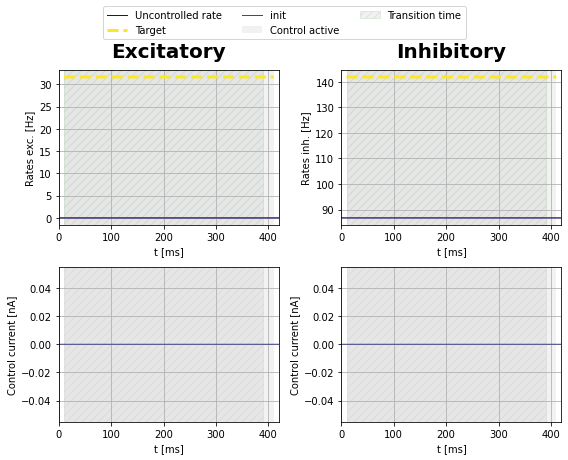

--------- 145


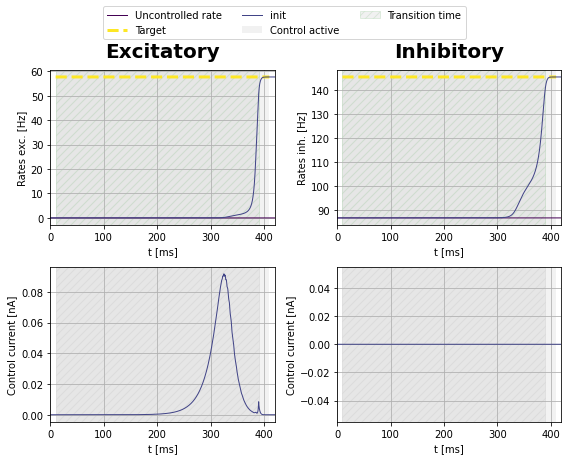

In [15]:

#plot initial guesses
for i in i_range:
    print("---------", i)
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
    plt.show()


In [16]:
found_solution = []
no_solution = []
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])    


    if np.abs(np.mean(bestState_init[i][0,0,-300:]) - target[i][0,0,-1]) < 0.1 * np.abs(
        np.mean(bestState_init[i][0,0,-100:]) - bestState_init[i][0,0,0]) and np.abs(
        np.mean(bestState_init[i][0,1,-300:]) - target[i][0,1,-1]) < 0.1 * np.abs(
        np.mean(bestState_init[i][0,1,-100:]) - bestState_init[i][0,1,0]) and np.amax(
        bestState_init[i][0,0,:]) < target[i][0,0,-1] + 5. and np.amax(
        bestState_init[i][0,1,:]) < target[i][0,1,-1] + 5.:
        # and np.amin(bestState_init[i][0,0,:]) > bestState_init[i][0,0,0] - 1.
        #and np.amin(bestState_init[i][0,1,:]) > bestState_init[i][0,1,0] - 1.:
        if i not in found_solution:
            print("found solution for ", i)
            found_solution.append(i)
        if i in no_solution:
            no_solution.pop(no_solution.index(i))
        

-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  5 0.4000000000000001 0.40000000000000013
found solution for  5
-------  10 0.4250000000000001 0.42500000000000016
found solution for  10
-------  15 0.4500000000000001 0.4500000000000002
found solution for  15
-------  20 0.4500000000000001 0.4750000000000002
found solution for  20
-------  25 0.4250000000000001 0.5000000000000002
-------  30 0.4250000000000001 0.5250000000000002
-------  35 0.5500000000000003 0.5250000000000002
found solution for  35
-------  40 0.5250000000000001 0.5500000000000003
found solution for  40
-------  45 0.5000000000000002 0.5750000000000003
found solution for  45
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
found solution for  60
-------  65 0.5000000000000002 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  75 0.5750000000000002 0.67500000000

In [17]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [18]:
factor_iteration = 20
conv_0 = [[False]*2] * len(exc)
full_converge = False

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 20:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break
        
    counter += 1
    
    for i in i_range_0:
        print("------- ", i, exc[i], inh[i])
        
        if conv_0[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

    # exc and inh control current 

        setinit(initVars[i], aln)
        aln.params.duration = dur

        if not type(bestControl_0[i]) == type(None):
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
        else:
            control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
            weights_0[i] = weights_init[i]
            cost_0[i] = cost_init[i]

        cgv = None
        max_it = 500 * factor_iteration

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                           + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        with open(final_file,'wb') as f:
            pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                     costnode_0, weights_0], f)
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
weight =  4565.061323953685
set cost params:  1.0 0.0 4565.061323953685
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5898.954457173973
Gradient descend method:  None
RUN  1 , total integrated cost =  5897.603840979848
RUN  2 , total integrated cost =  5895.402801923136
RUN  3 , total integrated cost =  5894.363503833223
RUN  4 , total integrated cost =  5893.277538218245
RUN  5 , total integrated cost =  5892.247687470823

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  968 , total integrated cost =  4457.3229003792485
Improved over  968  iterations in  115.96952096745372  seconds by  24.43876397522436  percent.
Problem in initial value trasfer:  Vmean_exc -56.626691800636486 -56.626698857237244
no convergence
-------  5 0.4000000000000001 0.40000000000000013
weight =  1623.1091826613238
set cost params:  1.0 0.0 1623.1091826613238
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5093.819595618996
Gradient descend method:  None
RUN  1 , total integrated cost =  5093.666776751727
RUN  2 , total integrated cost =  5093.460077128127
RUN  3 , total integrated cost =  5093.210780902854
RUN  4 , total integrated cost =  5092.944154182735
RUN  5 , total integrated cost =  5092.726476982063
RUN  6 , total integrated cost =  5092.507798113131
RUN  7 , total integrated cost =  5092.2496126666365
RUN  8 , total integrated cost =  5091.939848990769
RUN  9 , total integrated cost =  5091.707475524106
RUN

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  2133 , total integrated cost =  3903.600082210871
Improved over  2133  iterations in  317.87702162750065  seconds by  23.365953408161303  percent.
Problem in initial value trasfer:  Vmean_exc -56.625208223774926 -56.62520110981975
no convergence
-------  10 0.4250000000000001 0.42500000000000016
weight =  2901.695726769684
set cost params:  1.0 0.0 2901.695726769684
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9107.117658560657
Gradient descend method:  None
RUN  1 , total integrated cost =  9107.080015262089
RUN  2 , total integrated cost =  9107.055900877664
RUN  3 , total integrated cost =  9107.033305310988
RUN  4 , total integrated cost =  9107.03268595691
RUN  5 , total integrated cost =  9107.010698405353
RUN  6 , total integrated cost =  9106.99355930706
RUN  7 , total integrated cost =  9106.991878129365
RUN  8 , total integrated cost =  9106.98799593805
RUN  9 , total integrated cost =  9106.984412393362
RUN  10

...

RUN  3 , total integrated cost =  5094.891895569782
Control only changes marginally.
RUN  3 , total integrated cost =  5094.891895569782
Improved over  3  iterations in  1.410795085132122  seconds by  8.526512829121202e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.625412507117424 -56.625394040558916
converged for  5
-------  10 0.4250000000000001 0.42500000000000016
-------  15 0.4500000000000001 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  25 0.4250000000000001 0.5000000000000002
-------  30 0.4250000000000001 0.5250000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  40 0.5250000000000001 0.5500000000000003
-------  45 0.5000000000000002 0.5750000000000003
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
-------  65 0.5000000000000002 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  75 0

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5094.891895572134
Control only changes marginally.
RUN  1 , total integrated cost =  5094.891895572134
Improved over  1  iterations in  0.5030745845288038  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.625412507117424 -56.625394040558916
no convergence
-------  10 0.4250000000000001 0.42500000000000016
-------  15 0.4500000000000001 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  25 0.4250000000000001 0.5000000000000002
-------  30 0.4250000000000001 0.5250000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  40 0.5250000000000001 0.5500000000000003
-------  45 0.5000000000000002 0.5750000000000003
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
-------  65 0.5000000000000002 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  75 0.5750000000000002 0

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5094.89189557216
Control only changes marginally.
RUN  1 , total integrated cost =  5094.89189557216
Improved over  1  iterations in  0.5028371028602123  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.625412507117424 -56.625394040558916
converged for  5
-------  10 0.4250000000000001 0.42500000000000016
-------  15 0.4500000000000001 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  25 0.4250000000000001 0.5000000000000002
-------  30 0.4250000000000001 0.5250000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  40 0.5250000000000001 0.5500000000000003
-------  45 0.5000000000000002 0.5750000000000003
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
-------  65 0.5000000000000002 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  75 0.5750000000000002 0

In [19]:
"""
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
"""

'\nfor i in i_range_0:\n    \n    aln.params.mue_ext_mean = exc[i] * 5.\n    aln.params.mui_ext_mean = inh[i] * 5.\n\n    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],\n        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,\n        dur_pre, dur_post, initVars[i], target[i], \'\', filename_ = \'\', transition_time_ = trans_time,\n        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)\n'

In [20]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [21]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    if counter > 20:
        break
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        
        if conv_1[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        if not type(bestControl_1[i]) == type(None):
            control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1].copy()
        else:
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1].copy()
            cost_1[i] = cost_0[i]
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(final_file_1,'wb') as f:
            pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)
            
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
    counter += 1

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  59.93174777741955
Gradient descend method:  None
RUN  1 , total integrated cost =  1.1209792377753667
RUN  2 , total integrated cost =  1.0832627548312808
RUN  3 , total integrated cost =  1.0756278217133737
RUN  4 , total integrated cost =  1.072263279590534
RUN  5 , total integrated cost =  1.0705292782234401
RUN  6 , total integrated cost =  1.0

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  115 , total integrated cost =  2.477309460766982
Improved over  115  iterations in  7.907482696697116  seconds by  95.7515411729689  percent.
Problem in initial value trasfer:  Vmean_exc -56.624467995185206 -56.624467861337344
no convergence
-------  10 0.4250000000000001 0.42500000000000016
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  42.24805984825282
Gradient descend method:  None
RUN  1 , total integrated cost =  2.6056788054947475
RUN  2 , total integrated cost =  2.5717370494593585
RUN  3 , total integrated cost =  2.5633357969544712
RUN  4 , total integrated cost =  2.559938964069082
RUN  5 , total integrated cost =  2.5580883367714926
RUN  6 , total integrated cost =  2.556875293735828
RUN  7 , total integrated cost =  2.5559026218534746
RUN  8 , total integrated cost =  2.5551064778688364
RUN  9 , total integrated cost =  2.554380888745666
RUN  10 , total integrated cost =  2.5537178

RUN  800 , total integrated cost =  3.8025553748220893
RUN  900 , total integrated cost =  3.802116082106034
RUN  1000 , total integrated cost =  3.801818177671966
RUN  1100 , total integrated cost =  3.8017833460353887
RUN  1200 , total integrated cost =  3.799309443233259
RUN  1300 , total integrated cost =  3.799287451443416
RUN  1400 , total integrated cost =  3.798974702685394
RUN  1500 , total integrated cost =  3.7989384966774122
RUN  1600 , total integrated cost =  3.798927865177328
RUN  1700 , total integrated cost =  3.79892475099738
RUN  1800 , total integrated cost =  3.7989215814608173
RUN  1900 , total integrated cost =  3.7989144524872294
RUN  2000 , total integrated cost =  3.7988249801187672
RUN  3000 , total integrated cost =  3.7986131169571404
Control only changes marginally.
RUN  3515 , total integrated cost =  3.798608593030373
Improved over  3515  iterations in  233.5695581175387  seconds by  81.52038863268547  percent.
no convergence
-------  25 0.42500000000000

RUN  700 , total integrated cost =  2.2254781159888735
RUN  800 , total integrated cost =  2.2253572093874707
RUN  900 , total integrated cost =  2.225348428552286
RUN  1000 , total integrated cost =  2.2253459836102127
RUN  1100 , total integrated cost =  2.2253406218995897
RUN  1200 , total integrated cost =  2.2252091999694543
RUN  1300 , total integrated cost =  2.22520190053472
RUN  1400 , total integrated cost =  2.2252012297670984
RUN  1500 , total integrated cost =  2.225196914703643
RUN  1600 , total integrated cost =  2.225167367147617
RUN  1700 , total integrated cost =  2.2251670782728215
RUN  1800 , total integrated cost =  2.225096336184193
RUN  1900 , total integrated cost =  2.225092158172409
RUN  2000 , total integrated cost =  2.2250705494443754
RUN  3000 , total integrated cost =  2.2249280761214125
RUN  4000 , total integrated cost =  2.22490646706825
RUN  5000 , total integrated cost =  2.224886283953689
RUN  6000 , total integrated cost =  2.224856322854333
RUN  7

...

RUN  3 , total integrated cost =  3.8865375034555263
RUN  4 , total integrated cost =  3.886537361052815
RUN  5 , total integrated cost =  3.8865372935978826
RUN  6 , total integrated cost =  3.8865372792685955
RUN  7 , total integrated cost =  3.8865371763594494
RUN  8 , total integrated cost =  3.8865371353044567
RUN  9 , total integrated cost =  3.8865371254529077
RUN  10 , total integrated cost =  3.886536872973366
RUN  11 , total integrated cost =  3.886536711501387
RUN  12 , total integrated cost =  3.8865367025768567
RUN  13 , total integrated cost =  3.886535803881792
RUN  14 , total integrated cost =  3.8865351467845106
RUN  15 , total integrated cost =  3.8865351343642134
RUN  16 , total integrated cost =  3.8865350220001837
RUN  17 , total integrated cost =  3.8865349768622965
RUN  18 , total integrated cost =  3.8865349645706915
RUN  19 , total integrated cost =  3.886534822501269
RUN  20 , total integrated cost =  3.886534754781866
RUN  30 , total integrated cost =  3.8865

RUN  1300 , total integrated cost =  3.884502578937229
RUN  1400 , total integrated cost =  3.8844641489832563
RUN  1500 , total integrated cost =  3.8844393745487023
RUN  1600 , total integrated cost =  3.8843721099661224
RUN  1700 , total integrated cost =  3.8843484001017345
RUN  1800 , total integrated cost =  3.884340390686417
RUN  1900 , total integrated cost =  3.8843078404921974
RUN  2000 , total integrated cost =  3.884300233640728
RUN  3000 , total integrated cost =  3.8841679360965866
RUN  4000 , total integrated cost =  3.8839249452225126
RUN  5000 , total integrated cost =  3.8837759897388264
RUN  6000 , total integrated cost =  3.8834210624471077
RUN  7000 , total integrated cost =  3.8833336970727235
RUN  8000 , total integrated cost =  3.8832789154008185
RUN  9000 , total integrated cost =  3.883166626762049
RUN  10000 , total integrated cost =  3.8830996539952563
RUN  10000 , total integrated cost =  3.8830996539952563
Improved over  10000  iterations in  658.634183274

RUN  3 , total integrated cost =  3.8745489593480684
RUN  4 , total integrated cost =  3.874548948054222
RUN  5 , total integrated cost =  3.874548942654484
RUN  6 , total integrated cost =  3.8745486569359677
RUN  7 , total integrated cost =  3.8745484663479273
RUN  8 , total integrated cost =  3.8745484616620787
RUN  9 , total integrated cost =  3.874548438761347
RUN  10 , total integrated cost =  3.8745483607735003
RUN  11 , total integrated cost =  3.8745483494467488
RUN  12 , total integrated cost =  3.874548344057217
RUN  13 , total integrated cost =  3.874548058932068
RUN  14 , total integrated cost =  3.874547867818331
RUN  15 , total integrated cost =  3.87454786312645
RUN  16 , total integrated cost =  3.874547840303549
RUN  17 , total integrated cost =  3.874547762287246
RUN  18 , total integrated cost =  3.8745477509275346
RUN  19 , total integrated cost =  3.874547745548192
RUN  20 , total integrated cost =  3.8745474610168333
RUN  30 , total integrated cost =  3.874546643

RUN  1300 , total integrated cost =  3.8704844036310266
RUN  1400 , total integrated cost =  3.8703983290944675
RUN  1500 , total integrated cost =  3.870383420449276
RUN  1600 , total integrated cost =  3.870370447489989
RUN  1700 , total integrated cost =  3.870358068738754
RUN  1800 , total integrated cost =  3.8703448836547194
RUN  1900 , total integrated cost =  3.8703327850437956
RUN  2000 , total integrated cost =  3.870233377128885
RUN  3000 , total integrated cost =  3.8700232776931505
RUN  4000 , total integrated cost =  3.86975193707164
RUN  5000 , total integrated cost =  3.8692445104637727
RUN  6000 , total integrated cost =  3.868742977071253
RUN  7000 , total integrated cost =  3.86524502537819
RUN  8000 , total integrated cost =  3.8646995774744064
RUN  9000 , total integrated cost =  3.8641350209966117
RUN  10000 , total integrated cost =  3.8637373919941846
RUN  10000 , total integrated cost =  3.8637373919941846
Improved over  10000  iterations in  651.4936119578779 

RUN  3 , total integrated cost =  3.859837072067036
RUN  4 , total integrated cost =  3.859837065736619
RUN  5 , total integrated cost =  3.8598370641384045
RUN  6 , total integrated cost =  3.8598370515949765
RUN  7 , total integrated cost =  3.859836998704796
RUN  8 , total integrated cost =  3.8598369923741966
RUN  9 , total integrated cost =  3.8598369907757752
RUN  10 , total integrated cost =  3.859836978231391
RUN  11 , total integrated cost =  3.8598369253428997
RUN  12 , total integrated cost =  3.859836919012114
RUN  13 , total integrated cost =  3.8598369174134906
RUN  14 , total integrated cost =  3.859836904868143
RUN  15 , total integrated cost =  3.8598368519813357
RUN  16 , total integrated cost =  3.8598368456503676
RUN  17 , total integrated cost =  3.8598368440515403
RUN  18 , total integrated cost =  3.859836831505228
RUN  19 , total integrated cost =  3.859836778620112
RUN  20 , total integrated cost =  3.859836772288959
RUN  30 , total integrated cost =  3.8598366